# AI Exam (Ex 3)

An advanced aquatic drone is deployed to collect critical data on marine biodiversity in a coastal region. The drone starts at point $S$, located near the shore, and must navigate to point $G$, a designated marine research site rich in coral reefs and sea life. Along the way, the drone must carefully maneuver through dynamic underwater environments, avoiding hazards and optimizing energy usage.

The environment includes:  
1. **(O) Open Water:** Normal movement; no additional challenges.  
2. **(C) Currents:** Areas where ocean currents influence the drone's movement, potentially pushing it off course.  
3. **(F) Seaweed Forests:** Dense vegetation that slows the drone, incurring extra energy costs per move.    
4. **(R) Rocky Areas:** Dangerous zones that the drone must avoid, we do not know what happens to the agent if it enters in the cell.  
5. **(E) Energy Stations:** Specific points where the drone can recharge its battery, adding a small reward to encourage efficient navigation.  


<img src="images/env_ex3.png" style="zoom: 20%;"/>



### Environment Details:
The partial information on the enviroment you have are:
- **Grid Representation:** The above image represents the environment (a grid 10x10).  
- $S$ - Start state: The drone's starting point at (0, 0).  
- $G$ - Goal state: The marine research site at (9, 7) providing a large positive reward +20.0 and ending the episode.  
- **Movement Costs:** Each move has a default energy cost of -0.01.  
- **Hazards:**  
  - **Strong Currents:** Entering a current zone imposes a stochastic movement:  
    - 80% chance to move as intended.  
    - 10% chance to be pushed one cell in the left direction of the current.  
    - 10% chance to be pushed one cell in the right direction of the current. 
  - **Seaweed Forests:** Entering these zones incurs an additional -0.1 reward penalty.
  - **Rocky areas:** For these areas the model for the dynamics of the drones and the reward is not available
- **Energy Stations:** Provide a 0.1 reward when visited, (however reaching these cells may require the agent to move far from the goal).   

Consider the problem of computing the optimal solution for the environment reported above. You can interact with the environment using the code reported here below: 

[['S' 'O' 'O' 'F' 'F' 'C' 'R' 'R' 'R' 'R']
 ['O' 'R' 'R' 'C' 'C' 'C' 'F' 'E' 'F' 'F']
 ['O' 'O' 'F' 'C' 'R' 'C' 'F' 'F' 'F' 'F']
 ['R' 'R' 'F' 'C' 'E' 'C' 'F' 'O' 'F' 'R']
 ['O' 'F' 'F' 'C' 'R' 'C' 'F' 'O' 'F' 'R']
 ['R' 'E' 'F' 'R' 'R' 'O' 'F' 'C' 'F' 'R']
 ['O' 'F' 'C' 'C' 'C' 'O' 'F' 'C' 'F' 'C']
 ['O' 'F' 'F' 'F' 'O' 'O' 'O' 'F' 'F' 'C']
 ['O' 'O' 'O' 'O' 'R' 'R' 'R' 'R' 'F' 'R']
 ['R' 'R' 'R' 'O' 'O' 'O' 'O' 'G' 'O' 'F']]


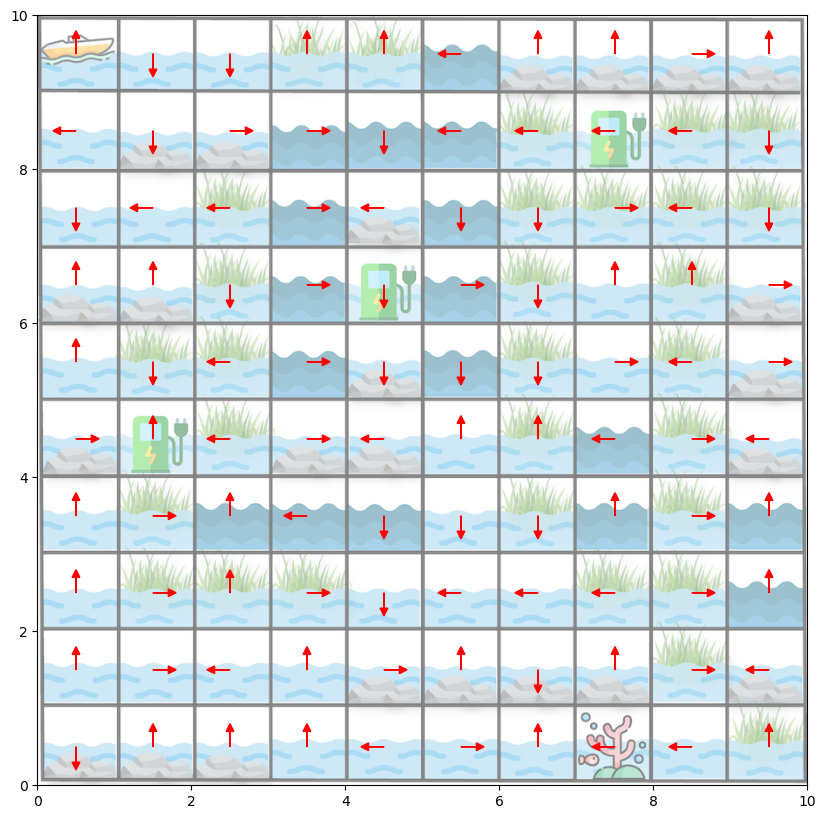

In [1]:
import os, sys 
import tqdm

module_path = os.path.abspath(os.path.join('tools'))
if module_path not in sys.path:
    sys.path.append(module_path)

import gym, envs
from utils.ai_lab_functions import *
import numpy as np
from timeit import default_timer as timer
from tqdm import tqdm as tqdm

env_name = 'AquaticEnv-v0'
env = gym.make(env_name)

env.render()

# you can visualize the policy of a solution by calling the plot_policy function
policy = np.random.choice(list(env.actions.keys()), env.observation_space.n)
visual_policy = np.vectorize(env.actions.get)(policy.reshape(env.rows, env.cols)) 
plot_policy(visual_policy)

In [2]:
print("\nActions encoding: ", env.actions)

# Remember that you can know the type of a cell whenever you need by accessing the grid element of the environment:
print("Cell type of start state: ",env.grid[env.startstate])
print("Cell type of goal state: {} Reward: {}".format(env.grid[env.goalstate],env.RS[env.goalstate]))

state = 15 # normal state
print(f"Cell type of cell {env.state_to_pos(state)}: ",env.grid[state])
print(f"Probability of effectivelty performing action {env.actions[0]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[0], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[1]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[1], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[2]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[2], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[3]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[3], state+1]}")

state = 10 # state with stochastic transitions
print(f"\nCell type of cell {env.state_to_pos(state)}: ",env.grid[state])
print(f"Probability of effectivelty performing action {env.actions[0]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[0], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[1]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[1], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[2]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[2], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[3]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[3], state+1]}")

state = 10 # state with stochastic transitions
print(f"\nCell type of cell {env.state_to_pos(state)}: ",env.grid[state])
print(f"Probability of effectivelty performing action {env.actions[0]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[0], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[1]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[1], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[2]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[2], state+1]}")
print(f"Probability of effectivelty performing action {env.actions[3]} from cell {env.state_to_pos(state)} to cell {env.state_to_pos(state+1)}: {env.T[state, list(env.actions.keys())[3], state+1]}")



Actions encoding:  {0: 'L', 1: 'R', 2: 'U', 3: 'D'}
Cell type of start state:  S
Cell type of goal state: G Reward: 20.0
Cell type of cell (1, 5):  C
Probability of effectivelty performing action L from cell (1, 5) to cell (1, 6): 0.0
Probability of effectivelty performing action R from cell (1, 5) to cell (1, 6): 0.8
Probability of effectivelty performing action U from cell (1, 5) to cell (1, 6): 0.1
Probability of effectivelty performing action D from cell (1, 5) to cell (1, 6): 0.1

Cell type of cell (1, 0):  O
Probability of effectivelty performing action L from cell (1, 0) to cell (1, 1): 0.0
Probability of effectivelty performing action R from cell (1, 0) to cell (1, 1): 1.0
Probability of effectivelty performing action U from cell (1, 0) to cell (1, 1): 0.0
Probability of effectivelty performing action D from cell (1, 0) to cell (1, 1): 0.0

Cell type of cell (1, 0):  O
Probability of effectivelty performing action L from cell (1, 0) to cell (1, 1): 0.0
Probability of effective

#### Q1: Provide an algorithm that finds a solution that reaches the goal without touching any 'R' state and passing through at least one charging station in this environment. Use the approach that you think is most appropriate motivating your choice.

# Approccio alla soluzione del problema

## Informazioni che abbiamo sull'ambiente

Dobbiamo usare un algoritmo di Reinforcement Learning perché dobbiamo tenere traccia dello stato dell'agente
mentre esegue le azioni all'interno dell'ambiente. Non può essere un MDP perché non abbiamo la possibilità di capire
dove passa l'agente durante l'esecuzione. Inoltre, non si conosce la probabilità di transizione delle zone rocciose. Quindi eviteremo approcci Model-based come le MDP e useremo un approccio Model-free come Q-learning o Sarsa. Quindi l'agente non conosce nulla sull'environment e dobbiamo "provare" azioni/stati e ottenere la ricompensa.

## Sarsa VS Q-Learning

Sarsa ci permette di prendere la strada più sicura perché ci evita di andare nelle correnti (C) che potrebbero rischiare di allungarci il 
percorso. Abbiamo quindi notato che sia SARSA che Q-Learning arrivano al GOAL, ma SARSA prende la strada più "sicura" mentre QL quella ottimale.

## Modifica dell'algoritmo 

La modifica che abbiamo apportato è stata quella di aggiungere una flag di nome "charged" che una volta attraversata una cella
di tipo E, viene settata a true. Quando questa flag è settata a false, il reward che viene dato all'agente se è arrivato al traguardo
senza passare da una charging station è di -10. Con i successivi episodi, è obbligato a passare per una charging station almeno una volta per 
eliminare la penalizzazione ed arrivare al traguardo in positivo.


In [3]:
def epsilon_greedy(q, state, epsilon):
    """
    Epsilon-greedy action selection function
    
    Args:
        q: q table
        state: agent's current state
        epsilon: epsilon parameter
    
    Returns:
        action id
    """
    if np.random.random() < epsilon: #enters the if only if the random number is less than epsilon (i.e., with probability  epsilon)
        return np.random.choice(q.shape[1]) #the size of first dimension of q is number of states, the second is number of actions 
    return q[state].argmax() #q[state] is a vector of q-values indexed by actions

def softmax(q, state, temp):
    """
    Softmax action selection function
    
    Args:
    q: q table
    state: agent's current state
    temp: temperature parameter
    
    Returns:
        action id
    """
    e = np.exp(q[state] / temp) #a vector indexed by action where each value is e^(q(s,a)/T)
    return np.random.choice(q.shape[1], p=e / e.sum()) # choose an action with probability e^(q(s,a)/T)/sum_{a'} e^(q(s,a')/T)  

In [ ]:
def q_learning(environment, episodes, alpha, gamma, expl_func, expl_param):
    """
    Performs the Q-Learning algorithm for a specific environment
    
    Args:
        environment: OpenAI Gym environment
        episodes: number of episodes for training
        alpha: alpha parameter
        gamma: gamma parameter
        expl_func: exploration function (epsilon_greedy, softmax)
        expl_param: exploration parameter (epsilon or T)
    
    Returns:
        (policy, rewards, lengths): final policy, rewards for each episode [array], length of each episode [array]
    """
    
    q = np.zeros((environment.observation_space.n, environment.action_space.n))  # Initialize Q table
    rews = np.zeros(episodes) # Initialize rewards array
    lengths = np.zeros(episodes) # Initialize lengths array
    
    for i in range(episodes):
        state = environment.reset() # Reset environment to start a new episode
        done = False
        charged = False
        # Repeat until s is terminal
        while not done:
            a = expl_func(q, state, expl_param)
            # Once a step is done, the environment returns the new state, the reward and if the episode is done
            new_state, reward, done, _ = environment.step(a) # Take action

            # If the agent reaches the charging station then it becomes charged
            if environment.grid[state] == "E":
                charged = True

            # If not charged then the agent receives a reward of -10 and the episode ends
            if not charged and done:
                reward = -10

            q[state, a] += alpha * (reward + gamma * q[new_state].max() - q[state, a]) # Q-Learning update
            state = new_state
            # Update rewards and lengths
            rews[i] += reward
            lengths[i] = lengths[i] + 1 # Update length at the i-th episode
    
    policy = q.argmax(axis=1) # q.argmax(axis=1) automatically extract the policy from the q table
    return policy, rews, lengths


In [ ]:
def sarsa(environment, episodes, alpha, gamma, expl_func, expl_param):
    """
    Performs the SARSA algorithm for a specific environment
    
    Args:
        environment: OpenAI gym environment
        episodes: number of episodes for training
        alpha: alpha parameter
        gamma: gamma parameter
        expl_func: exploration function (epsilon_greedy, softmax)
        expl_param: exploration parameter (epsilon, T)
    
    Returns:
        (policy, rewards, lengths): final policy, rewards for each episode [array], length of each episode [array]
    """
    q = np.zeros((environment.observation_space.n, environment.action_space.n))  # Initialize Q table
    rews = np.zeros(episodes) # Initialize rewards array
    lengths = np.zeros(episodes) # Initialize lengths array

    for i in range(episodes):
        state = environment.reset() # Reset environment to start a new episode
        action = expl_func(q, state, expl_param) # Choose action using exploration function
        done = False
        charged = False
        # Repeat until s is terminal
        while not done:
            next_state, reward, done, _ = environment.step(action)

            # If the agent is in an energy station then it becomes charged
            if environment.grid[state] == "E":
                charged = True

            # If not charged then penalize if the episode is done
            if not charged and done:
                reward = -10
                
            next_action = expl_func(q, next_state, expl_param)
            q[state, action] += alpha * (reward + gamma * q[next_state, next_action] - q[state, action]) # SARSA update
            rews[i] += reward
            lengths[i] += 1
            state = next_state
            action = next_action

    
    policy = q.argmax(axis=1) # q.argmax(axis=1) automatically extract the policy from the q table
    return policy, rews, lengths

def rl_solution(environment, algorithm, episodes, alpha, gamma, expl_func, expl_param, seed=None):
    if seed is not None:
        np.random.seed(seed)
    
    sol, _, _ = algorithm(environment, episodes, alpha, gamma, expl_func, expl_param)
    return sol


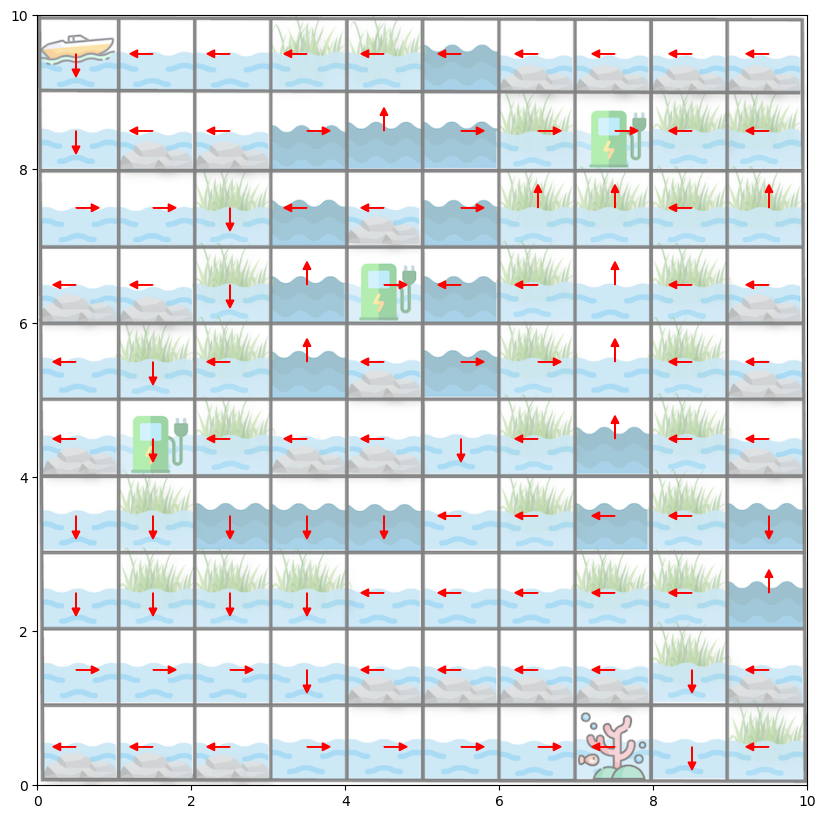

In [8]:
env_name = 'AquaticEnv-v0'
env = gym.make(env_name)

# for reproducibility purposes you can set a seed to your algorithm. For instance:
seed = None
sol = rl_solution(env, sarsa, episodes=5000, alpha=0.1, gamma=0.9, expl_func=softmax, expl_param=0.1, seed=seed)

# you can visualize the policy of a solution by calling the plot_policy function
#using a random policy for now, you should replace this with your solution 
visual_policy = np.vectorize(env.actions.get)(sol.reshape(env.rows, env.cols)) 
plot_policy(visual_policy)